In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive.zip


In [ ]:
import os

print(os.listdir())

['.config', 'archive.zip', 'sample_data']


In [ ]:
import zipfile

with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')


In [ ]:
import os

for root, dirs, files in os.walk('/content'):
    for file in files:
        print(os.path.join(root, file))

/content/archive.zip
/content/zomato.csv
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/active_config
/content/.config/.last_survey_prompt.yaml
/content/.config/.last_update_check.json
/content/.config/.last_opt_in_prompt.yaml
/content/.config/config_sentinel
/content/.config/default_configs.db
/content/.config/gce
/content/.config/logs/2026.06.04/13.32.38.346437.log
/content/.config/logs/2026.06.04/13.32.39.344962.log
/content/.config/logs/2026.06.04/13.32.02.654775.log
/content/.config/logs/2026.06.04/13.32.21.210570.log
/content/.config/logs/2026.06.04/13.31.42.499627.log
/content/.config/logs/2026.06.04/13.32.18.735754.log
/content/.config/configurations/config_default
/content/sample_data/anscombe.json
/content/sample_data/README.md
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/mnist_test.csv
/content/sample_data/california_housing_test.csv


In [ ]:
import pandas as pd

df = pd.read_csv('/content/zomato.csv')
print(df.shape)
df.head()

(51717, 17)


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [ ]:
df.isnull().sum()

,0
url,0
address,0
name,0
online_order,0
book_table,0
rate,7775
votes,0
phone,1208
location,21
rest_type,227


In [ ]:
df.isnull().sum().sort_values(ascending=False)


,0
dish_liked,28078
rate,7775
phone,1208
approx_cost(for two people),346
rest_type,227
cuisines,45
location,21
url,0
address,0
votes,0


In [ ]:
df = df.dropna()

In [ ]:
df = df.dropna(subset=['rate'])

In [ ]:
df['cuisines'] = df['cuisines'].fillna('Unknown')
df['location'] = df['location'].fillna('Unknown')
df['rest_type'] = df['rest_type'].fillna('Unknown')

In [ ]:
print(df['approx_cost(for two people)'].dtype)

object


In [ ]:
df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)']
    .astype(str)
    .str.replace(',', '', regex=False)
)

df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'],
    errors='coerce'
)

In [ ]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].fillna(
    df['approx_cost(for two people)'].median()
)

In [ ]:
print(df['approx_cost(for two people)'].dtype)
print(df['approx_cost(for two people)'].isnull().sum())

int64
0


In [ ]:
df['approx_cost(for two people)'].head(20)

,approx_cost(for two people)
0,800
1,800
2,800
3,300
4,600
5,600
7,600
8,700
9,550
10,500


In [ ]:
print(df.shape)
print(df.columns)
df.head()

(23193, 17)
Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')


,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [ ]:
df['rate'] = df['rate'].astype(str).str.replace('/5', '')
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

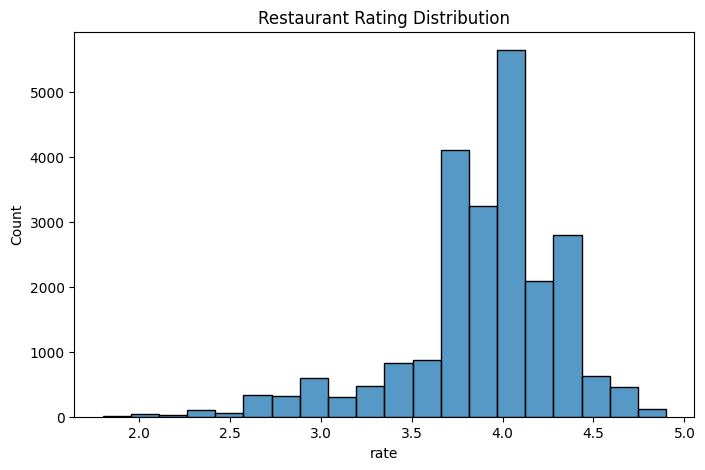

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['rate'].dropna(), bins=20)
plt.title('Restaurant Rating Distribution')
plt.show()

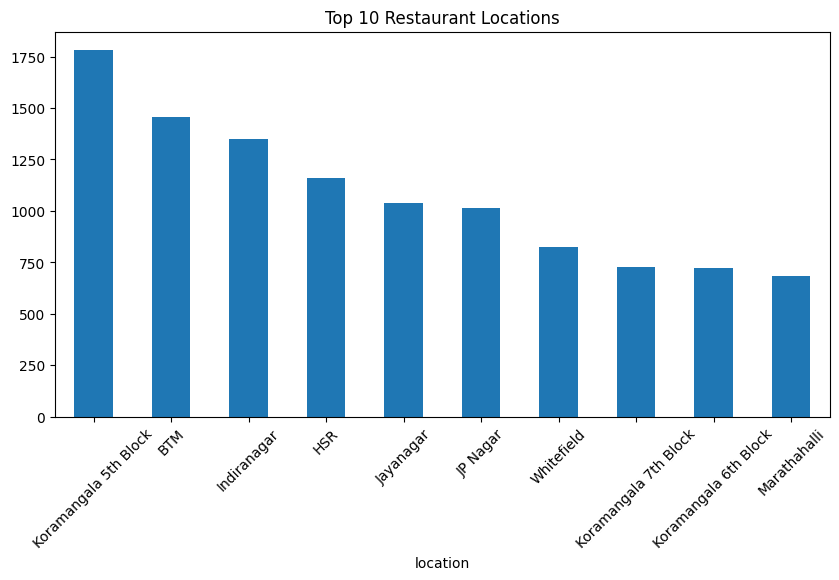

In [ ]:
top_locations = df['location'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_locations.plot(kind='bar')
plt.title('Top 10 Restaurant Locations')
plt.xticks(rotation=45)
plt.show()

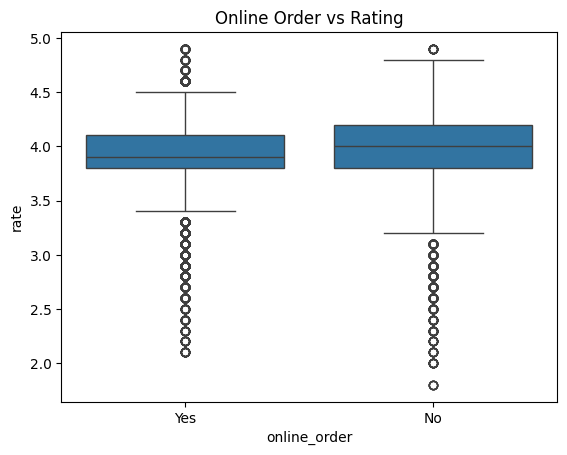

In [ ]:
sns.boxplot(data=df, x='online_order', y='rate')
plt.title('Online Order vs Rating')
plt.show()

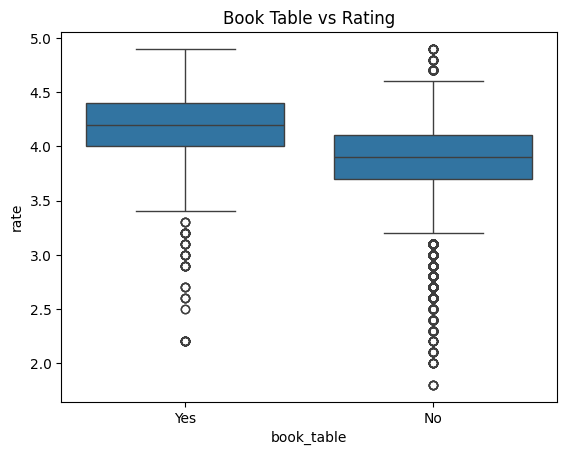

In [ ]:
sns.boxplot(data=df, x='book_table', y='rate')
plt.title('Book Table vs Rating')
plt.show()

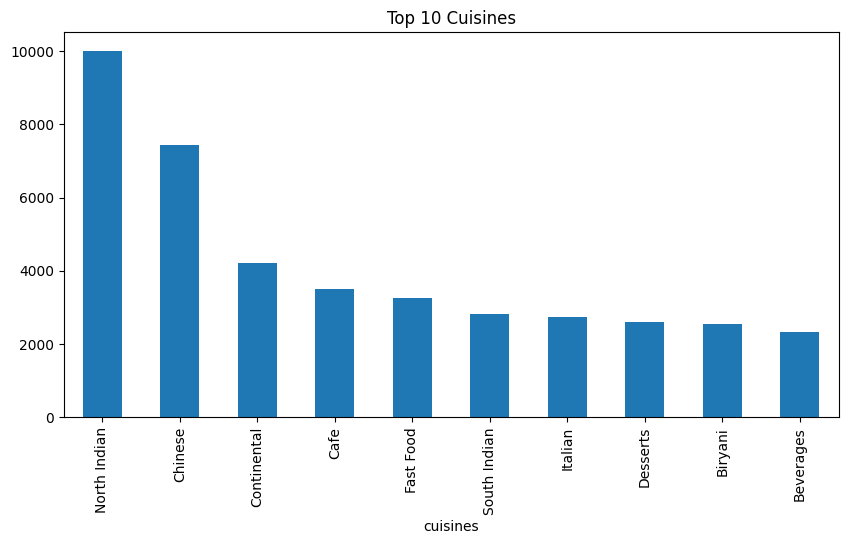

In [ ]:
cuisines = df['cuisines'].dropna().str.split(', ')
top_cuisines = cuisines.explode().value_counts().head(10)

plt.figure(figsize=(10,5))
top_cuisines.plot(kind='bar')
plt.title('Top 10 Cuisines')
plt.show()

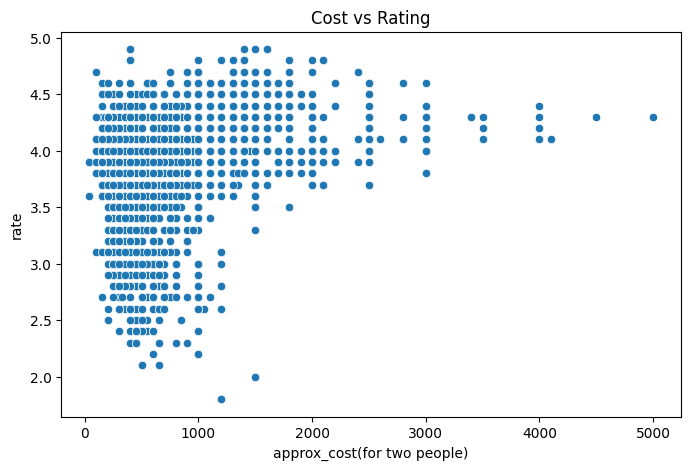

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df.sample(5000),
    x='approx_cost(for two people)',
    y='rate'
)
plt.title('Cost vs Rating')
plt.show()

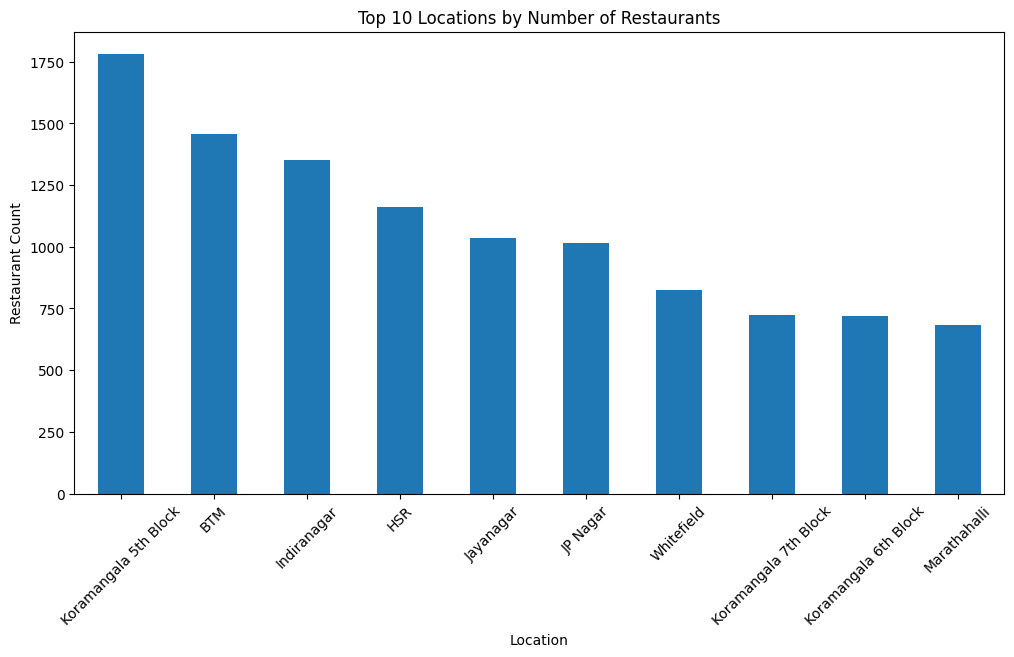

In [ ]:
top_locations = df['location'].value_counts().head(10)

plt.figure(figsize=(12,6))
top_locations.plot(kind='bar')
plt.title('Top 10 Locations by Number of Restaurants')
plt.xlabel('Location')
plt.ylabel('Restaurant Count')
plt.xticks(rotation=45)
plt.show()

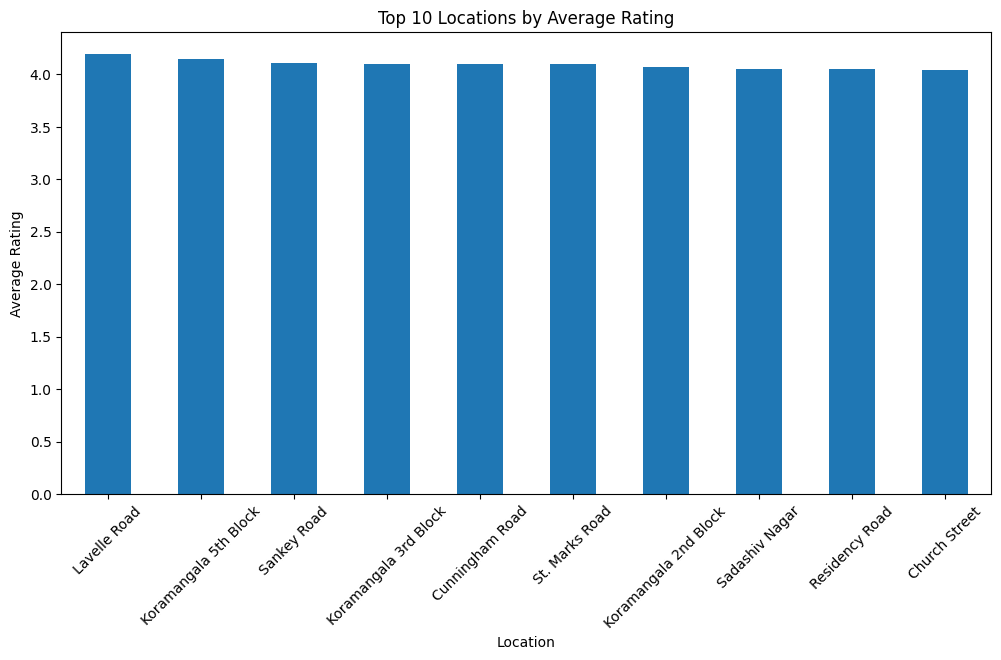

In [ ]:
location_rating = df.groupby('location')['rate'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
location_rating.plot(kind='bar')
plt.title('Top 10 Locations by Average Rating')
plt.xlabel('Location')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()

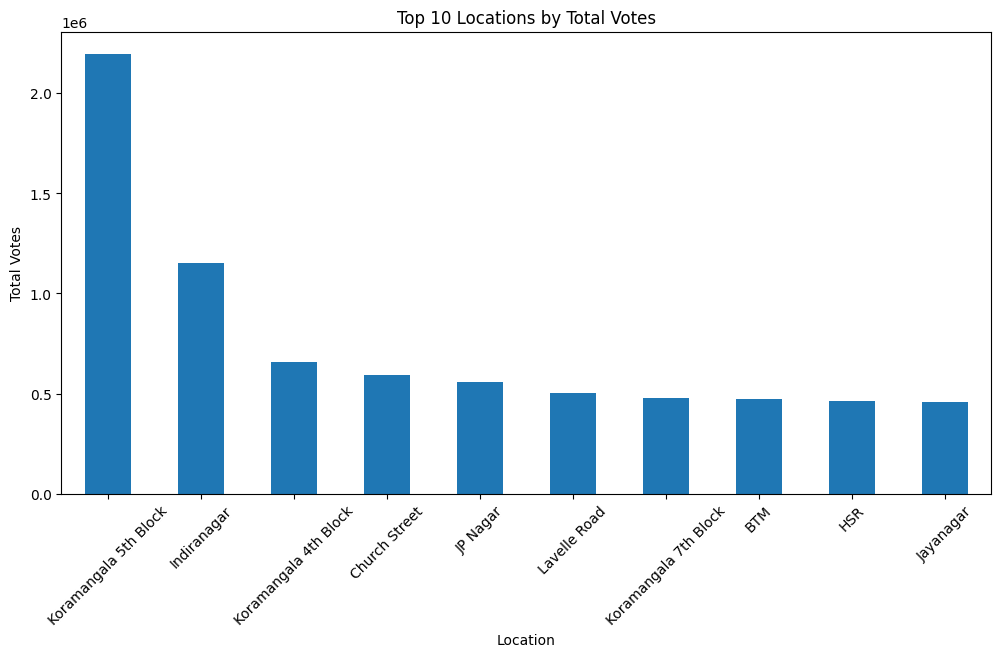

In [ ]:
location_votes = df.groupby('location')['votes'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
location_votes.plot(kind='bar')
plt.title('Top 10 Locations by Total Votes')
plt.xlabel('Location')
plt.ylabel('Total Votes')
plt.xticks(rotation=45)
plt.show()

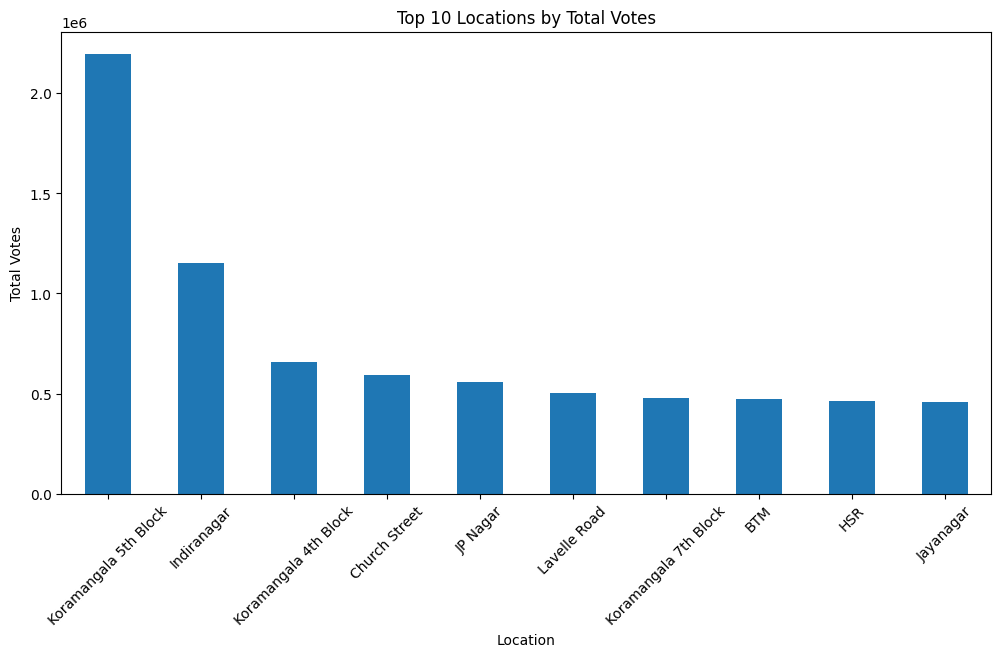

In [ ]:
location_votes = df.groupby('location')['votes'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
location_votes.plot(kind='bar')
plt.title('Top 10 Locations by Total Votes')
plt.xlabel('Location')
plt.ylabel('Total Votes')
plt.xticks(rotation=45)
plt.show()

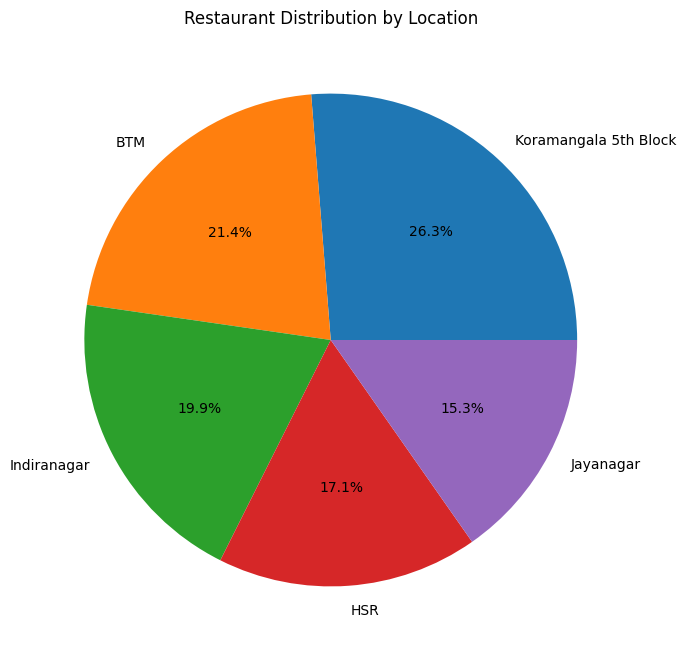

In [ ]:
top_locations = df['location'].value_counts().head(5)

plt.figure(figsize=(8,8))
plt.pie(top_locations.values,
        labels=top_locations.index,
        autopct='%1.1f%%')
plt.title('Restaurant Distribution by Location')
plt.show()

In [ ]:
df['online_order'].value_counts()

,count
online_order,
Yes,16358
No,6835


In [ ]:
online_percent = df['online_order'].value_counts(normalize=True) * 100
print(online_percent)

online_order
Yes    70.529901
No     29.470099
Name: proportion, dtype: float64


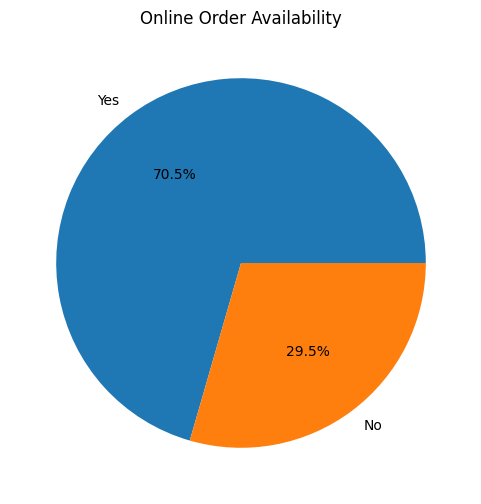

In [ ]:
import matplotlib.pyplot as plt

online_count = df['online_order'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    online_count.values,
    labels=online_count.index,
    autopct='%1.1f%%'
)
plt.title('Online Order Availability')
plt.show()

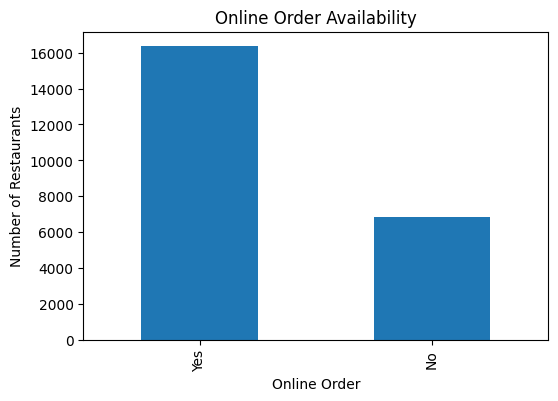

In [ ]:
online_count = df['online_order'].value_counts()

plt.figure(figsize=(6,4))
online_count.plot(kind='bar')
plt.title('Online Order Availability')
plt.xlabel('Online Order')
plt.ylabel('Number of Restaurants')
plt.show()

In [ ]:
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

In [ ]:
high_rating_count = df[df['rate'] > 4].shape[0]

print("Restaurants with rating above 4:", high_rating_count)

Restaurants with rating above 4: 8889


In [ ]:
total_restaurants = df.shape[0]

percentage = (high_rating_count / total_restaurants) * 100

print(f"Restaurants with rating above 4: {high_rating_count}")
print(f"Percentage: {percentage:.2f}%")

Restaurants with rating above 4: 8889
Percentage: 38.33%


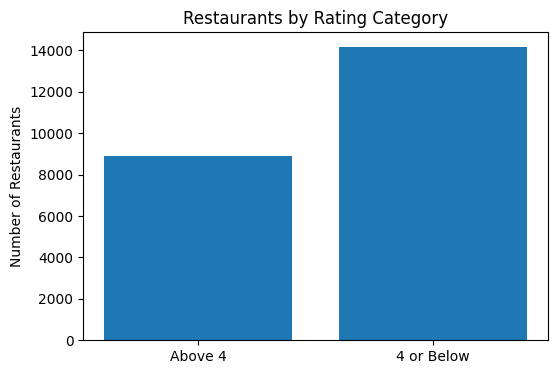

In [ ]:
rating_category = {
    'Above 4': len(df[df['rate'] > 4]),
    '4 or Below': len(df[df['rate'] <= 4])
}

plt.figure(figsize=(6,4))
plt.bar(rating_category.keys(), rating_category.values())
plt.title('Restaurants by Rating Category')
plt.ylabel('Number of Restaurants')
plt.show()

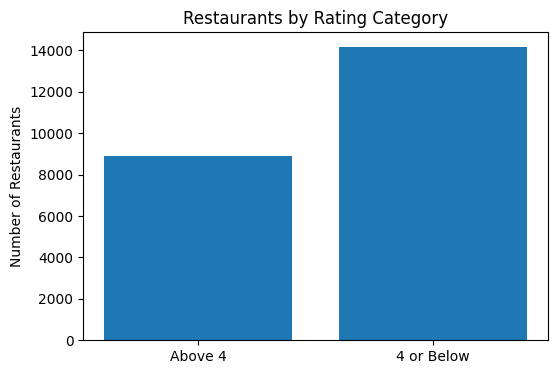

In [ ]:
rating_category = {
    'Above 4': len(df[df['rate'] > 4]),
    '4 or Below': len(df[df['rate'] <= 4])
}

plt.figure(figsize=(6,4))
plt.bar(rating_category.keys(), rating_category.values())
plt.title('Restaurants by Rating Category')
plt.ylabel('Number of Restaurants')
plt.show()

In [ ]:
high_rating_locations = (
    df[df['rate'] > 4]
    .groupby('location')
    .size()
    .sort_values(ascending=False)
    .head(20)
)

print(high_rating_locations)

location
Koramangala 5th Block    1183
Indiranagar               639
Jayanagar                 400
Lavelle Road              361
Koramangala 4th Block     358
JP Nagar                  333
Koramangala 7th Block     325
MG Road                   313
Church Street             292
Koramangala 6th Block     291
HSR                       278
BTM                       257
Whitefield                253
Ulsoor                    245
Residency Road            234
Brigade Road              228
Sarjapur Road             200
Richmond Road             192
Cunningham Road           192
Kalyan Nagar              191
dtype: int64


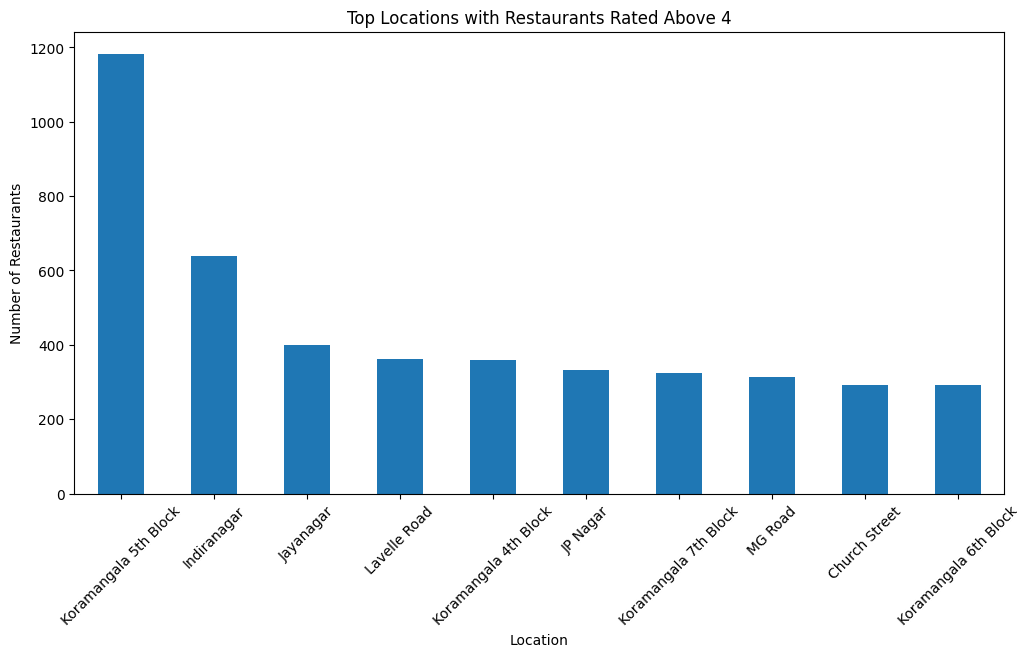

In [ ]:
import matplotlib.pyplot as plt

high_rating_locations = (
    df[df['rate'] > 4]
    .groupby('location')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
high_rating_locations.plot(kind='bar')
plt.title('Top Locations with Restaurants Rated Above 4')
plt.xlabel('Location')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45)
plt.show()

In [ ]:
best_locations = (
    df.groupby('location')['rate']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(best_locations)

location
Lavelle Road             4.193034
Koramangala 5th Block    4.151705
Sankey Road              4.105882
Koramangala 3rd Block    4.100617
Cunningham Road          4.100300
St. Marks Road           4.099013
Koramangala 2nd Block    4.073333
Sadashiv Nagar           4.055263
Residency Road           4.051584
Church Street            4.046063
Name: rate, dtype: float64


In [ ]:
location_count = (
    df.groupby('location')
    .size()
    .sort_values(ascending=False)
)

print(location_count)

location
Koramangala 5th Block    1783
BTM                      1456
Indiranagar              1350
HSR                      1162
Jayanagar                1037
                         ... 
Magadi Road                 2
West Bangalore              2
Rajarajeshwari Nagar        2
Yelahanka                   2
KR Puram                    1
Length: 88, dtype: int64


In [ ]:
print(location_count.head(20))

location
Koramangala 5th Block    1783
BTM                      1456
Indiranagar              1350
HSR                      1162
Jayanagar                1037
JP Nagar                 1016
Whitefield                824
Koramangala 7th Block     725
Koramangala 6th Block     720
Marathahalli              683
Koramangala 4th Block     644
MG Road                   596
Brigade Road              570
Church Street             508
Bannerghatta Road         496
Ulsoor                    477
Kalyan Nagar              467
Koramangala 1st Block     466
Bellandur                 462
Sarjapur Road             456
dtype: int64


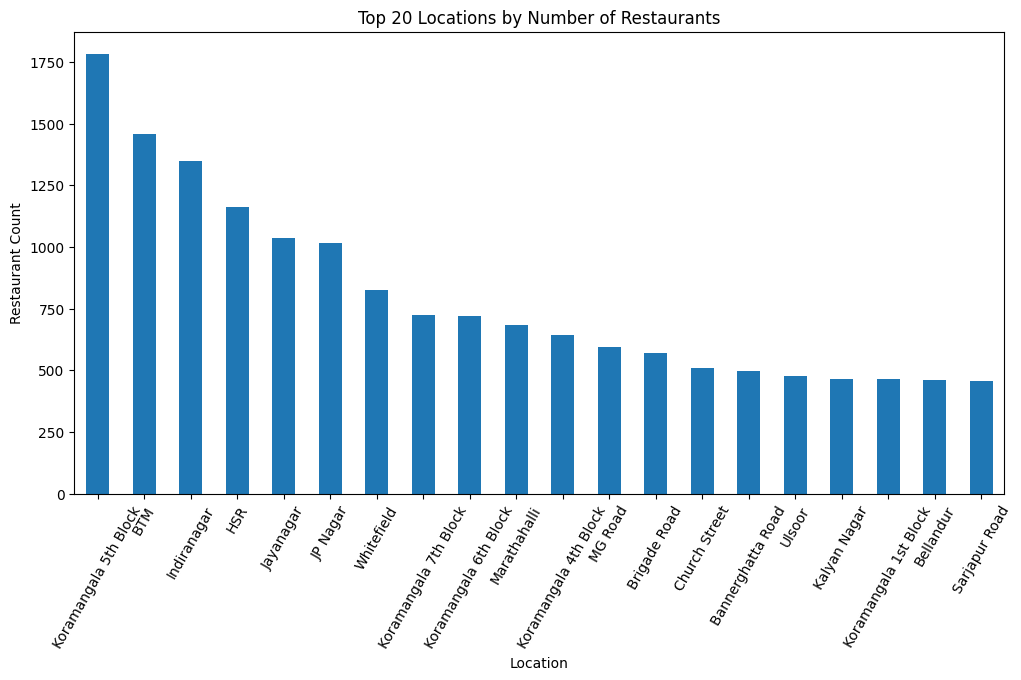

In [ ]:
import matplotlib.pyplot as plt

top_locations = (
    df.groupby('location')
    .size()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12,6))
top_locations.plot(kind='bar')
plt.title('Top 20 Locations by Number of Restaurants')
plt.xlabel('Location')
plt.ylabel('Restaurant Count')
plt.xticks(rotation=60)
plt.show()

In [ ]:
location_df = df.groupby('location').size().reset_index(name='Restaurant_Count')
location_df = location_df.sort_values('Restaurant_Count', ascending=False)

location_df.head(20)

,location,Restaurant_Count
42,Koramangala 5th Block,1783
0,BTM,1456
26,Indiranagar,1350
22,HSR,1162
30,Jayanagar,1037
28,JP Nagar,1016
84,Whitefield,824
44,Koramangala 7th Block,725
43,Koramangala 6th Block,720
53,Marathahalli,683


In [ ]:
df['rest_type'].value_counts().head(20)

,count
rest_type,
Casual Dining,7349
Quick Bites,5240
Cafe,2325
Dessert Parlor,1076
"Casual Dining, Bar",984
Delivery,670
Bar,357
"Bar, Casual Dining",343
"Takeaway, Delivery",343


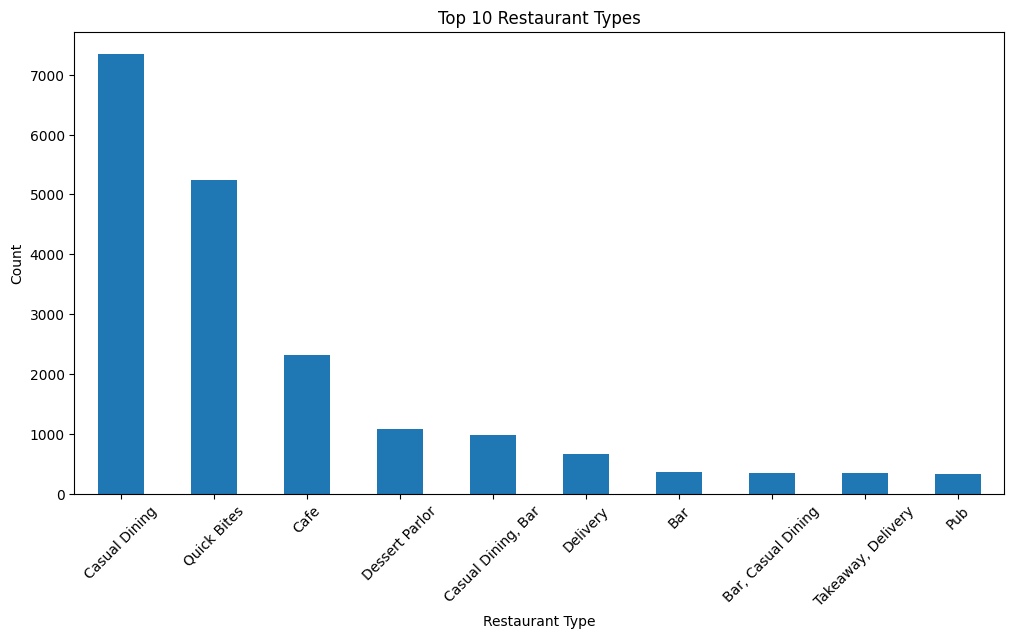

In [ ]:
import matplotlib.pyplot as plt

top_rest_types = df['rest_type'].value_counts().head(10)

plt.figure(figsize=(12,6))
top_rest_types.plot(kind='bar')
plt.title('Top 10 Restaurant Types')
plt.xlabel('Restaurant Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [ ]:
rest_type_percent = (
    df['rest_type'].value_counts(normalize=True) * 100
).head(10)

print(rest_type_percent)

rest_type
Casual Dining         31.686285
Quick Bites           22.593024
Cafe                  10.024576
Dessert Parlor         4.639331
Casual Dining, Bar     4.242659
Delivery               2.888803
Bar                    1.539258
Bar, Casual Dining     1.478894
Takeaway, Delivery     1.478894
Pub                    1.405597
Name: proportion, dtype: float64


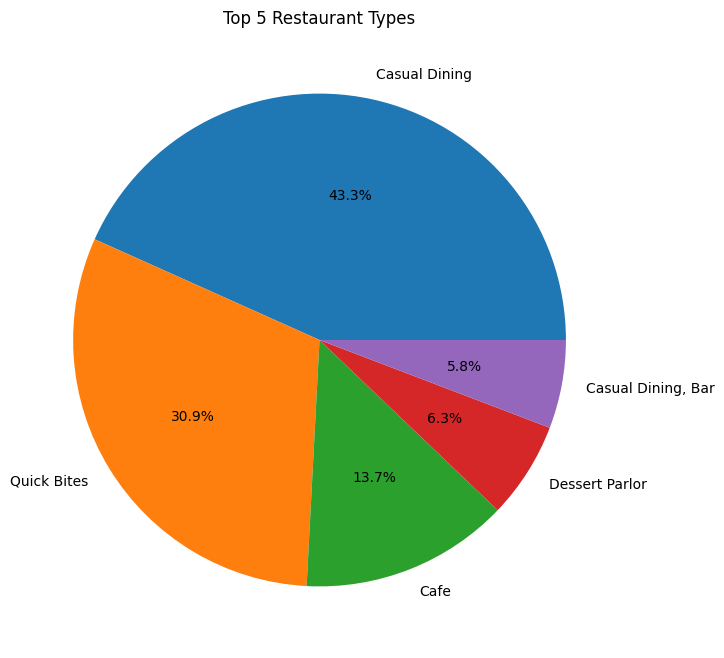

In [ ]:
top5 = df['rest_type'].value_counts().head(5)

plt.figure(figsize=(8,8))
plt.pie(
    top5.values,
    labels=top5.index,
    autopct='%1.1f%%'
)
plt.title('Top 5 Restaurant Types')
plt.show()

In [ ]:
rest_rating = (
    df.groupby('rest_type')['rate']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(rest_rating)

rest_type
Pub, Cafe                      4.657500
Bar, Pub                       4.600000
Microbrewery                   4.508333
Pub, Microbrewery              4.452632
Microbrewery, Bar              4.446154
Microbrewery, Pub              4.438095
Casual Dining, Irani Cafee     4.406667
Cafe, Lounge                   4.400000
Fine Dining, Lounge            4.400000
Microbrewery, Casual Dining    4.369421
Name: rate, dtype: float64


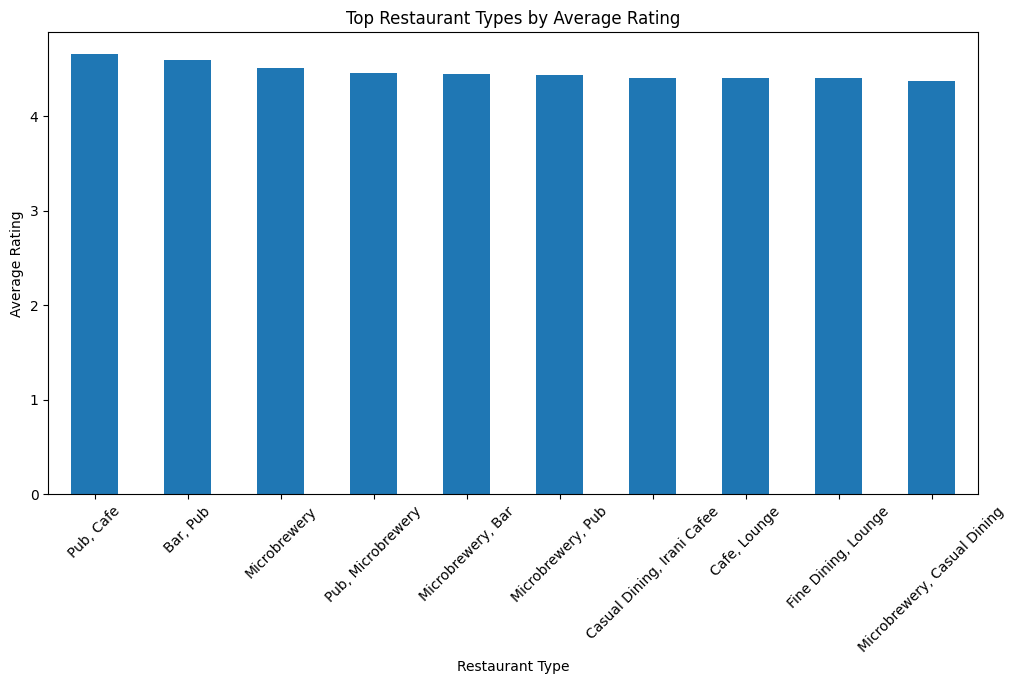

In [ ]:
plt.figure(figsize=(12,6))
rest_rating.plot(kind='bar')
plt.title('Top Restaurant Types by Average Rating')
plt.xlabel('Restaurant Type')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df['rest_type'].value_counts().head(10)

,count
rest_type,
Casual Dining,7349
Quick Bites,5240
Cafe,2325
Dessert Parlor,1076
"Casual Dining, Bar",984
Delivery,670
Bar,357
"Bar, Casual Dining",343
"Takeaway, Delivery",343


In [ ]:
df[['name','location','rate']].sort_values('rate', ascending=False).head(20)

,name,location,rate
35082,Asia Kitchen By Mainland China,Koramangala 5th Block,4.9
49627,Byg Brewski Brewing Company,Sarjapur Road,4.9
23587,AB's - Absolute Barbecues,BTM,4.9
34734,Asia Kitchen By Mainland China,Koramangala 5th Block,4.9
27453,Asia Kitchen By Mainland China,Koramangala 5th Block,4.9
39559,Punjab Grill,Malleshwaram,4.9
11504,Asia Kitchen By Mainland China,Koramangala 5th Block,4.9
49170,Byg Brewski Brewing Company,Sarjapur Road,4.9
37099,AB's - Absolute Barbecues,BTM,4.9
50059,Byg Brewski Brewing Company,Sarjapur Road,4.9


In [ ]:
df[['name','votes','location']].sort_values('votes', ascending=False).head(20)

,name,votes,location
50059,Byg Brewski Brewing Company,16832,Sarjapur Road
49170,Byg Brewski Brewing Company,16832,Sarjapur Road
49627,Byg Brewski Brewing Company,16832,Sarjapur Road
3921,Byg Brewski Brewing Company,16345,Sarjapur Road
4944,Byg Brewski Brewing Company,16345,Sarjapur Road
4801,Byg Brewski Brewing Company,16345,Sarjapur Road
18643,Toit,14956,Indiranagar
19268,Toit,14956,Indiranagar
36668,Truffles,14726,Koramangala 5th Block
33913,Truffles,14723,Koramangala 5th Block


In [ ]:
df.groupby('online_order')['rate'].mean()

,rate
online_order,
No,3.930227
Yes,3.893680


In [ ]:
df.groupby('book_table')['rate'].mean()

,rate
book_table,
No,3.813349
Yes,4.160636


In [ ]:
df.groupby('location')['approx_cost(for two people)'].mean().sort_values()

,approx_cost(for two people)
location,
KR Puram,300.000000
Hosur Road,327.083333
Yelahanka,350.000000
Sanjay Nagar,373.529412
Ejipura,377.966102
...,...
Infantry Road,1187.368421
Race Course Road,1284.000000
Lavelle Road,1425.505618


In [ ]:
cuisines = df['cuisines'].dropna().str.split(', ').explode()
cuisines.value_counts().head(20)

,count
cuisines,
North Indian,10020
Chinese,7446
Continental,4211
Cafe,3515
Fast Food,3259
South Indian,2820
Italian,2730
Desserts,2615
Biryani,2549


In [ ]:
df.groupby('cuisines')['rate'].mean().sort_values(ascending=False).head(20)

,rate
cuisines,
"Continental, North Indian, Italian, South Indian, Finger Food",4.900000
"Asian, Chinese, Thai, Momos",4.900000
"Healthy Food, Salad, Mediterranean",4.900000
"North Indian, European, Mediterranean, BBQ",4.800000
"Continental, North Indian, Chinese, European, BBQ, Finger Food, Asian",4.800000
"Asian, Mediterranean, North Indian, BBQ",4.800000
"European, Mediterranean, North Indian, BBQ",4.789474
"American, Tex-Mex, Burger, BBQ, Mexican",4.750000
"Continental, Asian, North Indian",4.723810


In [ ]:
location_rating = df.groupby('location')['rate'].mean().sort_values(ascending=False)
print(location_rating.head(20))

location
Lavelle Road             4.193034
Koramangala 5th Block    4.151705
Sankey Road              4.105882
Koramangala 3rd Block    4.100617
Cunningham Road          4.100300
St. Marks Road           4.099013
Koramangala 2nd Block    4.073333
Sadashiv Nagar           4.055263
Residency Road           4.051584
Church Street            4.046063
Koramangala 4th Block    4.044146
Seshadripuram            4.031884
Richmond Road            4.029060
Ulsoor                   4.021564
Koramangala              4.011765
Koramangala 7th Block    3.988982
Race Course Road         3.986667
Hosur Road               3.983333
Malleshwaram             3.966120
Indiranagar              3.962519
Name: rate, dtype: float64


In [ ]:
df[['rate','votes','approx_cost(for two people)']].corr()

,rate,votes,approx_cost(for two people)
rate,1.000000,0.382114,0.315253
votes,0.382114,1.000000,0.307821
approx_cost(for two people),0.315253,0.307821,1.000000


In [ ]:
top_locations = df['location'].value_counts().head(10)

In [ ]:
df[df['rate'] > 4]['location'].value_counts().head(20)

,count
location,
Koramangala 5th Block,1183
Indiranagar,639
Jayanagar,400
Lavelle Road,361
Koramangala 4th Block,358
JP Nagar,333
Koramangala 7th Block,325
MG Road,313
Church Street,292


In [ ]:
plt.savefig('top_locations.png', bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
from google.colab import files
files.download('top_locations.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from PIL import Image

img = Image.open('top_locations.png')
img = img.convert('RGB')
img.save('top_locations.pdf')

In [ ]:
from google.colab import files
files.download('top_locations.pdf')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>